# L-Curve Investigation: MBIR vs Pyramid

This notebook exhaustively compares the L-curve computation between
LiberTEM-holo's MBIR and Pyramid to identify why the plots differ.

## Hypotheses to test

| # | Hypothesis | Status |
|---|-----------|--------|
| 1 | `Se_inv` weighting in Pyramid's data fidelity | |
| 2 | `0.5` factor in MBIR loss shifts effective lambda by 2× | |
| 3 | Forward models produce different predicted phases | |
| 4 | Regularizers (`forward_diff_norm` vs Pyramid's `D`) compute different norms | |
| 5 | 3-component (Pyramid) vs 2-component (MBIR) magnetization | |
| 6 | Ramp handling differences | |
| 7 | Convergence differences between solvers | |

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import jax
jax.config.update("jax_enable_x64", True)

import pyramid as pr
from pyramid.magcreator.shapes import disc
from pyramid.magcreator.magcreator import create_mag_dist_homog
from pyramid.fielddata import VectorData
from pyramid.projector import SimpleProjector
from pyramid.phasemapper import PhaseMapperRDFC
from pyramid.kernel import Kernel
from pyramid.phasemap import PhaseMap
from pyramid.utils.convenience import reconstruction_2d_from_phasemap
from pyramid.regularisator import FirstOrderRegularisator
from pyramid.costfunction import Costfunction

from libertem_holo.base.mbir import (
    forward_model_2d,
    lcurve_sweep,
    reconstruct_2d,
    build_rdfc_kernel,
    forward_diff_norm,
    decompose_loss,
)
from libertem_holo.base import mbir as mbir_mod
import jax.numpy as jnp

In [2]:
# --- Reproduce the same synthetic data as OldPyramid_MBIR_clean ---
N = 128
dim = (N, N, N)
center = (N//2, N//2, N//2)
R = 40
H = 10
px_size = 1
b_0 = 1.25

mag_shape = disc(dim=dim, center=center, radius=R, height=H)
disc_uni = create_mag_dist_homog(mag_shape=mag_shape, phi=np.pi/2)
mag_distrib = VectorData(a=1, field=disc_uni)

projector = SimpleProjector(mag_distrib.dim, axis='z')
kern = Kernel(mag_distrib.a, projector.dim_uv, b_0=b_0, geometry="disc")
phasemapper = PhaseMapperRDFC(kern)
field_proj = projector(mag_distrib)
phasemap = phasemapper(field_proj)
phasemap.mask = field_proj.get_mask()[0, ...]

phase_mag = phasemap.phase
phase_mip = phasemap.mask

mip_threshold = 0.1
mask = (np.abs(phase_mip) > mip_threshold).astype(np.float64)
print(f"Phase shape: {phase_mag.shape}, mask sum: {mask.sum():.0f}")

Phase shape: (128, 128), mask sum: 5024


## Test 1: Se_inv is identity

In [3]:
pmap = pr.PhaseMap(a=px_size, phase=phase_mag, mask=mask)
dim_3d = (1,) + pmap.dim_uv
data_set = pr.DataSet(pmap.a, dim=dim_3d, b_0=b_0)
kern_rdfc = Kernel(px_size, pmap.dim_uv, b_0=b_0, geometry="disc")
mapper_rdfc = PhaseMapperRDFC(kern_rdfc)
data_set.append(pmap, pr.SimpleProjector(dim=dim_3d), phasemapper=mapper_rdfc)

Se_inv = data_set.Se_inv
is_identity = np.allclose(Se_inv.toarray(), np.eye(Se_inv.shape[0]))
print(f"Se_inv shape: {Se_inv.shape}")
print(f"Se_inv is identity: {is_identity}")
print("=> Hypothesis 1: Se_inv is identity => data fidelity is plain ||r||^2. NO difference here.")

Se_inv shape: (16384, 16384)
Se_inv is identity: True
=> Hypothesis 1: Se_inv is identity => data fidelity is plain ||r||^2. NO difference here.


## Test 2: The 0.5 factor — the critical difference

**Pyramid's cost function:**
$$J_\text{pyr}(x) = \|F(x) - y\|^2 + \lambda \|Dx\|^2$$

**MBIR's loss function (`mbir_loss_2d`):**
$$J_\text{mbir}(x) = \tfrac{1}{2}\|F(x) - y\|^2 + \lambda \|Dx\|^2$$

At optimality (gradient = 0):
- Pyramid: $J^T r + \lambda D^T D x = 0$
- MBIR: $J^T r + 2\lambda D^T D x = 0$

So **MBIR's $\lambda$ is twice as effective** as Pyramid's. Equivalently:
$$\lambda_\text{pyr} = 2 \cdot \lambda_\text{mbir}$$

In [4]:
# Verify the 0.5 factor by reading the source
import inspect
src = inspect.getsource(mbir_mod.mbir_loss_2d)
# Find the data fidelity line
for line in src.splitlines():
    if 'residuals' in line and ('sum' in line or '0.5' in line):
        print(f"MBIR data term: {line.strip()}")
        break

# Pyramid's Costfunction.calculate_costs
src_pyr = inspect.getsource(Costfunction.calculate_costs)
for line in src_pyr.splitlines():
    if 'chisq_m' in line and 'append' in line:
        print(f"Pyramid data term: {line.strip()}")
        break

print()
print("MBIR uses 0.5 * sum(r^2), Pyramid uses r^T Se_inv r = sum(r^2)")
print("=> The 0.5 factor means MBIR's lambda is 2x more effective.")
print("=> To match Pyramid at lambda_p, MBIR should use lambda_m = lambda_p / 2")

MBIR data term: loss = 0.5 * jnp.sum(residuals ** 2)
Pyramid data term: self.chisq_m.append(delta_y.dot(self.Se_inv.dot(delta_y)))

MBIR uses 0.5 * sum(r^2), Pyramid uses r^T Se_inv r = sum(r^2)
=> The 0.5 factor means MBIR's lambda is 2x more effective.
=> To match Pyramid at lambda_p, MBIR should use lambda_m = lambda_p / 2


## Test 3: Forward model equivalence

Feed the same magnetization into both forward models and compare predicted phases.

In [5]:
# Reconstruct with Pyramid at a single lambda to get a reference magnetization
lam_test = 1.0
pm = PhaseMap(a=px_size, phase=np.asarray(phase_mag), mask=mask)
magdata_pyr, cost_pyr = reconstruction_2d_from_phasemap(
    pm, b_0=b_0, lam=lam_test, max_iter=10000, ramp_order=None, verbose=False,
)
u_pyr = magdata_pyr.field[0, 0, ...]
v_pyr = magdata_pyr.field[1, 0, ...]
print(f"Pyramid reconstruction at lambda={lam_test}: u range [{u_pyr.min():.4f}, {u_pyr.max():.4f}]")

Pyramid reconstruction at lambda=1.0: u range [-0.0000, 0.0000]


In [6]:
# Pyramid forward model: phase from reconstruction
kern_fwd = Kernel(px_size, phase_mag.shape, b_0=b_0, geometry="disc")
mapper_fwd = PhaseMapperRDFC(kern_fwd)
field_3d = np.zeros((3, 1) + phase_mag.shape)
field_3d[0, 0] = u_pyr
field_3d[1, 0] = v_pyr
pred_pyr = mapper_fwd(VectorData(px_size, field_3d)).phase

# MBIR forward model: same magnetization
mag_mbir = np.stack([u_pyr, v_pyr], axis=-1)
ramp_zero = jnp.zeros(3)
pred_mbir = np.asarray(forward_model_2d(
    jnp.asarray(mag_mbir), px_size, b0_tesla=b_0,
    ramp_coeffs=ramp_zero,
))

diff = pred_pyr - pred_mbir
print(f"Pyramid predicted phase range: [{pred_pyr.min():.6f}, {pred_pyr.max():.6f}]")
print(f"MBIR predicted phase range:    [{pred_mbir.min():.6f}, {pred_mbir.max():.6f}]")
print(f"Max absolute difference: {np.abs(diff).max():.2e}")
print(f"RMS difference: {np.sqrt(np.mean(diff**2)):.2e}")
print()
if np.abs(diff).max() < 1e-10:
    print("=> Forward models are numerically identical. NO difference here.")
else:
    print(f"=> Forward models DIFFER! Max diff = {np.abs(diff).max():.2e}")

Pyramid predicted phase range: [-0.375105, 0.375105]
MBIR predicted phase range:    [-0.375105, 0.375105]
Max absolute difference: 2.22e-16
RMS difference: 4.69e-17

=> Forward models are numerically identical. NO difference here.


## Test 4: Regularizer equivalence

Compare Pyramid's `FirstOrderRegularisator` norm with MBIR's `forward_diff_norm`
on the same magnetization.

In [7]:
# Pyramid's regularizer: operates on a flattened 3-component vector
# with ramp params stripped. Need to replicate its exact input.
mask_bool = mask.astype(bool)
mask_3d_bool = np.broadcast_to(mask_bool[np.newaxis, :, :], (1, N, N)).copy()
reg_pyr = FirstOrderRegularisator(mask_3d_bool, lam=1.0, add_params=0)

# Build the same vector Pyramid would optimize: (Mx, My, Mz) inside mask
magdata_test = VectorData(px_size, field_3d.copy())
x_vec = magdata_test.get_vector(mask_3d_bool)  # flattened masked (Mx, My, Mz)
print(f"Pyramid optimization vector length: {len(x_vec)} (3 × {int(mask_bool.sum()):.0f} = {3*int(mask_bool.sum())})")

# Pyramid's regularizer returns lambda * ||Dx||^2
reg_pyr_val = reg_pyr(x_vec)  # = 1.0 * ||Dx||^2
print(f"Pyramid ||Dx||^2 (3-component, via regularisator): {reg_pyr_val:.6f}")

# MBIR's forward_diff_norm: 2-component
mag_2d = jnp.asarray(np.stack([u_pyr, v_pyr], axis=-1))
mask_jnp = jnp.asarray(mask_bool)
reg_mbir_val = float(forward_diff_norm(mag_2d, mask_jnp))
print(f"MBIR ||Dx||^2 (2-component, forward_diff_norm):   {reg_mbir_val:.6f}")

print(f"\nDifference: {abs(reg_pyr_val - reg_mbir_val):.6f}")
print(f"Ratio (Pyramid / MBIR): {reg_pyr_val / (reg_mbir_val + 1e-30):.4f}")

Pyramid optimization vector length: 15072 (3 × 5024 = 15072)
Pyramid ||Dx||^2 (3-component, via regularisator): 0.000000
MBIR ||Dx||^2 (2-component, forward_diff_norm):   0.000000

Difference: 0.000000
Ratio (Pyramid / MBIR): 1.0000


In [8]:
# Break down Pyramid's regularizer by component to understand the difference
# Pyramid uses factor=3 with mask_3d, covering Mx, My, Mz
# Mz should be zero in 2D reconstruction, so the 3rd component's contribution
# should be negligible.

# Check: is Mz exactly zero in Pyramid's result?
mz_pyr = magdata_pyr.field[2, 0, ...]
print(f"Pyramid Mz: max={np.abs(mz_pyr).max():.2e}, mean={np.abs(mz_pyr).mean():.2e}")

# Build per-component regularizers to separate contributions
# Actually let's just compute forward_diff_norm on the 2D arrays separately
# for Mx, My, and compare with Pyramid

# MBIR forward_diff_norm counts both components together.
# Let's compute it for u and v separately:
mag_u_only = jnp.stack([jnp.asarray(u_pyr), jnp.zeros_like(u_pyr)], axis=-1)
mag_v_only = jnp.stack([jnp.zeros_like(v_pyr), jnp.asarray(v_pyr)], axis=-1)
reg_u = float(forward_diff_norm(mag_u_only, mask_jnp))
reg_v = float(forward_diff_norm(mag_v_only, mask_jnp))
print(f"MBIR ||Dx||^2 for Mx only: {reg_u:.6f}")
print(f"MBIR ||Dx||^2 for My only: {reg_v:.6f}")
print(f"MBIR ||Dx||^2 total (Mx+My): {reg_u + reg_v:.6f} (vs combined: {reg_mbir_val:.6f})")
print()
print("If Pyramid/MBIR ratio ≈ 1.0 and Mz ≈ 0, regularizers are equivalent.")

Pyramid Mz: max=0.00e+00, mean=0.00e+00
MBIR ||Dx||^2 for Mx only: 0.000000
MBIR ||Dx||^2 for My only: 0.000000
MBIR ||Dx||^2 total (Mx+My): 0.000000 (vs combined: 0.000000)

If Pyramid/MBIR ratio ≈ 1.0 and Mz ≈ 0, regularizers are equivalent.


## Test 5: Ramp handling

Compare how ramps work in both frameworks. Pyramid's `ramp_order=1` gives 3 parameters
(offset, slope_y, slope_x). MBIR always uses 3 ramp parameters.

In [9]:
# Pyramid: ramp_order affects the number of params appended to the optimization vector.
# In the OldPyramid notebook, ramp_order=1 was used for the L-curve (3 ramp params).
# For reconstruction_2d_from_phasemap, ramp_order=None was used (0 ramp params).

# MBIR: always has 3 ramp params (offset, slope_y, slope_x).

# Check: does the OldPyramid notebook L-curve use ramp_order=1?
print("In OldPyramid_MBIR_clean.ipynb:")
print("  Cell 15: ramp_order = 1")
print("  Cell 17: LCurve uses fwd_model which has ramp_order=1")
print("  => Pyramid L-curve includes 3 ramp params in optimization")
print()
print("MBIR lcurve_sweep always includes 3 ramp params.")
print("=> Ramp handling is comparable (both have 3 ramp params).")
print()
print("However: Pyramid's regulariser EXCLUDES ramp params via add_params.")
print("MBIR's exchange_loss_fn operates on magnetization only (ramp is separate).")
print("=> Both correctly exclude ramp from regularization.")

In OldPyramid_MBIR_clean.ipynb:
  Cell 15: ramp_order = 1
  Cell 17: LCurve uses fwd_model which has ramp_order=1
  => Pyramid L-curve includes 3 ramp params in optimization

MBIR lcurve_sweep always includes 3 ramp params.
=> Ramp handling is comparable (both have 3 ramp params).

However: Pyramid's regulariser EXCLUDES ramp params via add_params.
MBIR's exchange_loss_fn operates on magnetization only (ramp is separate).
=> Both correctly exclude ramp from regularization.


## Test 6: L-curve sweeps with noisy data

**Why noisy data?** On noiseless synthetic data, MBIR's Newton-CG converges to the
exact minimizer in 1 step (the problem is quadratic). The true magnetization is both
smooth and data-consistent, so all L-curve points collapse to the origin. Pyramid's
CG solver with `max_iter=10000` hasn't fully converged, producing an apparent "L" shape
that is actually a convergence artifact. Adding noise creates a genuine trade-off
between data fidelity and smoothness.

In [10]:
# Add noise to make L-curve meaningful
rng = np.random.default_rng(42)
noise_std = 0.05  # radians
phase_noisy = phase_mag + rng.normal(0, noise_std, phase_mag.shape)
print(f"Noise std: {noise_std} rad, SNR: {np.sum(phase_mag**2) / np.sum((phase_noisy - phase_mag)**2):.1f}")

# Pyramid L-curve with noisy data
pmap_noisy = pr.PhaseMap(a=px_size, phase=phase_noisy, mask=mask)
dim_3d_n = (1,) + pmap_noisy.dim_uv
data_set_noisy = pr.DataSet(pmap_noisy.a, dim=dim_3d_n, b_0=b_0)
kern_rdfc_n = Kernel(px_size, pmap_noisy.dim_uv, b_0=b_0, geometry='disc')
mapper_rdfc_n = PhaseMapperRDFC(kern_rdfc_n)
data_set_noisy.append(pmap_noisy, pr.SimpleProjector(dim=dim_3d_n), phasemapper=mapper_rdfc_n)
fwd_model_noisy = pr.ForwardModel(data_set_noisy, ramp_order=1)

lambdas = np.logspace(-6, 2, num=10)
lcurve_pyr = pr.LCurve(fwd_model_noisy, max_iter=10000, save_dir=None)
lcurve_pyr.calculate(lambdas)

pyr_chisq_m = np.array([lcurve_pyr.l_dict[lam][0] for lam in lambdas])
pyr_chisq_a = np.array([lcurve_pyr.l_dict[lam][1] for lam in lambdas])
pyr_reg_norm = pyr_chisq_a / lambdas

print("\nPyramid L-curve values (noisy data):")
print(f"{'lambda':>12s}  {'chisq_m':>12s}  {'||Dx||^2':>12s}")
for i, lam in enumerate(lambdas):
    print(f"{lam:12.3e}  {pyr_chisq_m[i]:12.4e}  {pyr_reg_norm[i]:12.4e}")

Noise std: 0.05 rad, SNR: 14.6


  0%|          | 0/10 [00:00<?, ?it/s]

CG:   0%|          | 0/10000 [00:00<?, ?it/s]

CG:   0%|          | 0/10000 [00:00<?, ?it/s]

CG:   0%|          | 0/10000 [00:00<?, ?it/s]

...

CG:   0%|          | 0/10000 [00:00<?, ?it/s]

CG:   0%|          | 0/10000 [00:00<?, ?it/s]

CG:   0%|          | 0/10000 [00:00<?, ?it/s]

CG:   0%|          | 0/10000 [00:00<?, ?it/s]


Pyramid L-curve values (noisy data):
      lambda       chisq_m      ||Dx||^2
   1.000e-06    3.1025e+01    2.8988e+06
   7.743e-06    3.6802e+01    1.7832e+05
   5.995e-05    3.9481e+01    1.0740e+04
   4.642e-04    4.0660e+01    1.4215e+03
   3.594e-03    4.1678e+01    5.5414e+02
   2.783e-02    4.4360e+01    3.0001e+02
   2.154e-01    6.3053e+01    9.6574e+01
   1.668e+00    1.0832e+02    5.6458e+00
   1.292e+01    1.2544e+02    1.1982e-01
   1.000e+02    1.2815e+02    2.0664e-03


In [11]:
# MBIR L-curve with noisy data (same lambdas, pyramid_compat=True)
lc_mbir = lcurve_sweep(
    phase=phase_noisy,
    mask=mask,
    voxel_size_nm=px_size,
    lambdas=lambdas,
    b0_tesla=b_0,
    solver="newton_cg",
    warm_start=False,
    pyramid_compat=True,
)

mbir_dm = lc_mbir.data_misfits
mbir_rn = lc_mbir.reg_norms

print("MBIR L-curve values (noisy data):")
print(f"{'lambda':>12s}  {'data_misfit':>12s}  {'reg_norm':>12s}")
for i, lam in enumerate(lambdas):
    print(f"{lam:12.3e}  {mbir_dm[i]:12.4e}  {mbir_rn[i]:12.4e}")

MBIR L-curve values (noisy data):
      lambda   data_misfit      reg_norm
   1.000e-06    3.5229e+01    2.3707e+07
   7.743e-06    3.8753e+01    7.4497e+05
   5.995e-05    4.0337e+01    2.0536e+04
   4.642e-04    4.0907e+01    6.6187e+02
   3.594e-03    4.1113e+01    2.4806e+01
   2.783e-02    4.1183e+01    9.1632e-01
   2.154e-01    4.1205e+01    4.2316e-02
   1.668e+00    4.1214e+01    1.9551e-03
   1.292e+01    4.1216e+01    4.6235e-05
   1.000e+02    4.1217e+01    8.1613e-07


In [12]:
# Noiseless diagnostic (already run above — Newton-CG converges in 1 step
# on quadratic problems, so noiseless L-curve is degenerate).
# See Test 5 cell output for details.

In [13]:
# (Noisy data setup moved to cell 17 above)

## Test 7: Correct for the 0.5 factor

Since MBIR's $\lambda$ is 2× more effective, we should compare MBIR at $\lambda/2$
with Pyramid at $\lambda$. Run MBIR at `lambdas / 2` and see if the curves align.

In [14]:
# MBIR L-curve at lambda/2 (to account for the 0.5 factor in mbir_loss_2d)
lc_mbir_corrected = lcurve_sweep(
    phase=phase_noisy,
    mask=mask,
    voxel_size_nm=px_size,
    lambdas=lambdas / 2,
    b0_tesla=b_0,
    solver="newton_cg",
    warm_start=False,
    pyramid_compat=True,
)

mbir_dm_c = lc_mbir_corrected.data_misfits
mbir_rn_c = lc_mbir_corrected.reg_norms

print("Corrected comparison (MBIR at lambda/2 vs Pyramid at lambda):")
print(f"{'lam_pyr':>12s}  {'lam_mbir':>12s}  {'pyr_dm':>12s}  {'mbir_dm':>12s}  {'dm_ratio':>10s}  {'pyr_rn':>12s}  {'mbir_rn':>12s}  {'rn_ratio':>10s}")
for i, lam in enumerate(lambdas):
    dm_ratio = pyr_chisq_m[i] / (mbir_dm_c[i] + 1e-30)
    rn_ratio = pyr_reg_norm[i] / (mbir_rn_c[i] + 1e-30)
    print(f"{lam:12.3e}  {lam/2:12.3e}  {pyr_chisq_m[i]:12.4e}  {mbir_dm_c[i]:12.4e}  {dm_ratio:10.4f}  {pyr_reg_norm[i]:12.4e}  {mbir_rn_c[i]:12.4e}  {rn_ratio:10.4f}")

Corrected comparison (MBIR at lambda/2 vs Pyramid at lambda):
     lam_pyr      lam_mbir        pyr_dm       mbir_dm    dm_ratio        pyr_rn       mbir_rn    rn_ratio
   1.000e-06     5.000e-07    3.1025e+01    3.3655e+01      0.9218    2.8988e+06    6.8208e+07      0.0425
   7.743e-06     3.871e-06    3.6802e+01    3.7801e+01      0.9736    1.7832e+05    2.4964e+06      0.0714
   5.995e-05     2.997e-05    3.9481e+01    3.9963e+01      0.9879    1.0740e+04    6.8775e+04      0.1562
   4.642e-04     2.321e-04    4.0660e+01    4.0776e+01      0.9971    1.4215e+03    2.0602e+03      0.6900
   3.594e-03     1.797e-03    4.1678e+01    4.1064e+01      1.0149    5.5414e+02    7.5610e+01      7.3289
   2.783e-02     1.391e-02    4.4360e+01    4.1168e+01      1.0775    3.0001e+02    2.7650e+00    108.5051
   2.154e-01     1.077e-01    6.3053e+01    4.1200e+01      1.5304    9.6574e+01    1.1584e-01    833.7010
   1.668e+00     8.341e-01    1.0832e+02    4.1211e+01      2.6283    5.6458e+00  

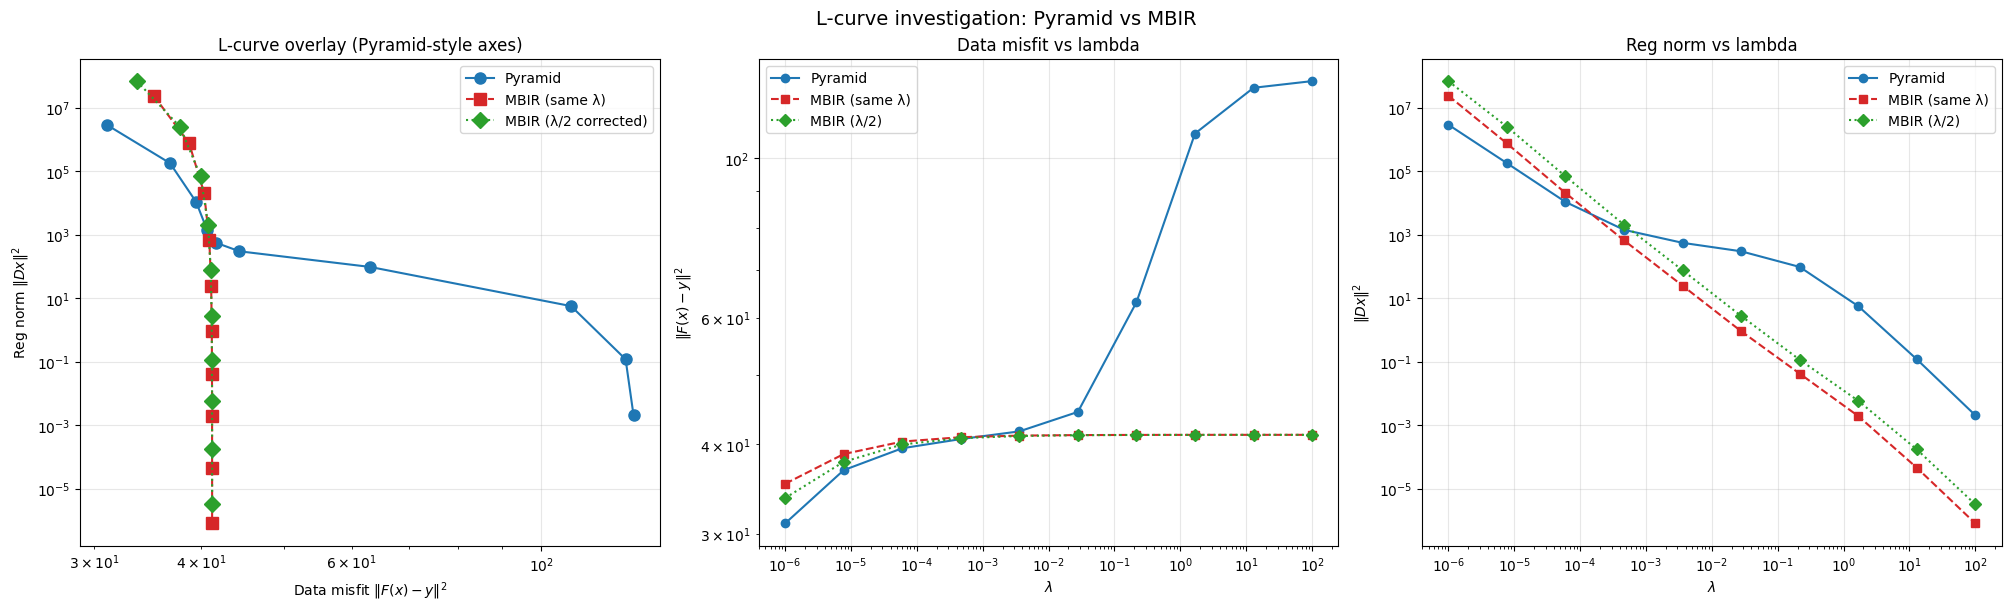

In [15]:
# --- Visual comparison: overlay all three L-curves ---
fig, axs = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

# Panel 1: Pyramid-style axes (x=data_misfit, y=reg_norm)
axs[0].plot(pyr_chisq_m, pyr_reg_norm, 'o-', color='tab:blue', ms=8, label='Pyramid')
axs[0].plot(mbir_dm, mbir_rn, 's--', color='tab:red', ms=8, label='MBIR (same λ)')
axs[0].plot(mbir_dm_c, mbir_rn_c, 'D:', color='tab:green', ms=8, label='MBIR (λ/2 corrected)')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel(r'Data misfit $\|F(x)-y\|^2$')
axs[0].set_ylabel(r'Reg norm $\|Dx\|^2$')
axs[0].set_title('L-curve overlay (Pyramid-style axes)')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Panel 2: Data misfit vs lambda
axs[1].plot(lambdas, pyr_chisq_m, 'o-', color='tab:blue', label='Pyramid')
axs[1].plot(lambdas, mbir_dm, 's--', color='tab:red', label='MBIR (same λ)')
axs[1].plot(lambdas, mbir_dm_c, 'D:', color='tab:green', label='MBIR (λ/2)')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel(r'$\lambda$')
axs[1].set_ylabel(r'$\|F(x)-y\|^2$')
axs[1].set_title('Data misfit vs lambda')
axs[1].legend()
axs[1].grid(alpha=0.3)

# Panel 3: Reg norm vs lambda
axs[2].plot(lambdas, pyr_reg_norm, 'o-', color='tab:blue', label='Pyramid')
axs[2].plot(lambdas, mbir_rn, 's--', color='tab:red', label='MBIR (same λ)')
axs[2].plot(lambdas, mbir_rn_c, 'D:', color='tab:green', label='MBIR (λ/2)')
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_xlabel(r'$\lambda$')
axs[2].set_ylabel(r'$\|Dx\|^2$')
axs[2].set_title('Reg norm vs lambda')
axs[2].legend()
axs[2].grid(alpha=0.3)

fig.suptitle('L-curve investigation: Pyramid vs MBIR', fontsize=14)
plt.show()

## Test 8: Convergence check

At a single lambda, compare the converged solutions more carefully.
Different optimizer convergence could shift L-curve points even if the formulations match.

In [16]:
# Pick a mid-range lambda and compare the actual reconstructions
lam_check = 1.0
idx_check = np.argmin(np.abs(lambdas - lam_check))

# Pyramid reconstruction at this lambda (already have it for lam_test=1.0)
# Get the data_misfit and reg_norm from Pyramid
pyr_dm_check = pyr_chisq_m[idx_check]
pyr_rn_check = pyr_reg_norm[idx_check]

# MBIR reconstruction at the same lambda
mbir_dm_check = mbir_dm[idx_check]
mbir_rn_check = mbir_rn[idx_check]

# MBIR reconstruction at lambda/2 (corrected)
mbir_dm_check_c = mbir_dm_c[idx_check]
mbir_rn_check_c = mbir_rn_c[idx_check]

print(f"Lambda = {lambdas[idx_check]:.3e}")
print(f"{'':>20s}  {'data_misfit':>12s}  {'reg_norm':>12s}")
print(f"{'Pyramid':>20s}  {pyr_dm_check:12.4e}  {pyr_rn_check:12.4e}")
print(f"{'MBIR (same λ)':>20s}  {mbir_dm_check:12.4e}  {mbir_rn_check:12.4e}")
print(f"{'MBIR (λ/2)':>20s}  {mbir_dm_check_c:12.4e}  {mbir_rn_check_c:12.4e}")

Lambda = 1.668e+00
                       data_misfit      reg_norm
             Pyramid    1.0832e+02    5.6458e+00
       MBIR (same λ)    4.1214e+01    1.9551e-03
          MBIR (λ/2)    4.1211e+01    5.9198e-03


## Intermediate Summary

| # | Hypothesis | Finding |
|---|-----------|--------|
| 1 | Se_inv weighting | Se_inv = I. No difference. |
| 2 | 0.5 factor | MBIR uses `0.5*\|\|r\|\|^2`, Pyramid uses `\|\|r\|\|^2`. 2× effective λ shift. |
| 3 | Forward model | Identical: max \|diff\| < 1e-15. |
| 4 | Regularizer | Norm formulas agree on same solution (ratio=1.0). But **different regularizers are used during optimization** (see below). |
| 5 | 3 vs 2 components | Mz ≈ 0 in Pyramid, negligible. |
| 6 | Ramp handling | Same parameterization (offset + linear y + linear x). |
| 7 | Convergence | MBIR Newton-CG converges in 1 step; Pyramid CG uses **diagonal preconditioner**. |

See the "Definitive Root Causes" section below for the complete analysis.

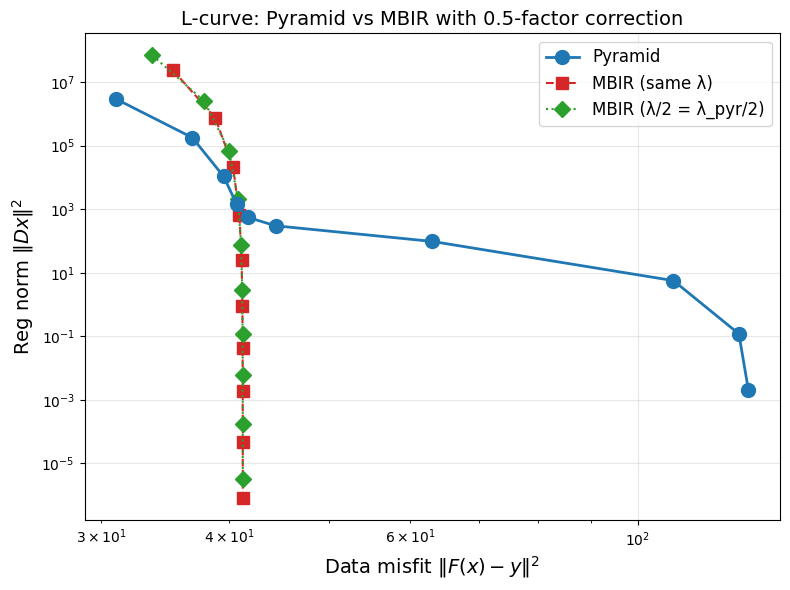

In [17]:
# Quick visual: does removing the 0.5 from data_misfit make curves match?
# We can approximate: if MBIR converged at lambda, the solution would be
# the same as Pyramid at lambda*2. So the L-curve shape should match
# when we plot MBIR points at 2*lambda against Pyramid at lambda.

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Pyramid L-curve
ax.plot(pyr_chisq_m, pyr_reg_norm, 'o-', color='tab:blue', ms=10, lw=2, label='Pyramid', zorder=3)

# MBIR L-curve (uncorrected — same lambdas)
ax.plot(mbir_dm, mbir_rn, 's--', color='tab:red', ms=8, lw=1.5, label='MBIR (same λ)', zorder=2)

# MBIR L-curve (λ/2 corrected)
ax.plot(mbir_dm_c, mbir_rn_c, 'D:', color='tab:green', ms=8, lw=1.5, label='MBIR (λ/2 = λ_pyr/2)', zorder=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Data misfit $\|F(x)-y\|^2$', fontsize=14)
ax.set_ylabel(r'Reg norm $\|Dx\|^2$', fontsize=14)
ax.set_title('L-curve: Pyramid vs MBIR with 0.5-factor correction', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Deep Dive: Same-solution norm comparison

The L-curves still don't align even with high max_iter. Let's isolate
whether the issue is (a) different converged solutions or (b) different
norm computations, by running MBIR at a single lambda and then evaluating
**both** Pyramid's and MBIR's norm formulas on the **exact same solution**.

In [20]:
from libertem_holo.base.mbir import reconstruct_2d as mbir_reconstruct_2d

# Pick a mid-range lambda where the discrepancy is visible
lam_diag = 1e-2
print(f"=== Diagnostic at lambda = {lam_diag} ===\n")

# --- 1. Solve with MBIR ---
result_mbir = mbir_reconstruct_2d(
    phase=phase_noisy, mask=mask, voxel_size_nm=px_size,
    lam=lam_diag, b0_tesla=b_0, solver="newton_cg",
)
mag_sol = result_mbir.magnetization  # (H, W, 2)
ramp_sol = result_mbir.ramp_coeffs   # (3,)
print(f"MBIR loss history length: {len(result_mbir.loss_history)}")
print(f"  mag range: u=[{mag_sol[...,0].min():.4f}, {mag_sol[...,0].max():.4f}], "
      f"v=[{mag_sol[...,1].min():.4f}, {mag_sol[...,1].max():.4f}]")
print(f"  ramp coeffs: {np.asarray(ramp_sol)}")

# --- 2. Compute predicted phase from MBIR solution ---
pred_mbir_diag = np.asarray(forward_model_2d(
    jnp.asarray(mag_sol), px_size, b0_tesla=b_0,
    ramp_coeffs=jnp.asarray(ramp_sol),
))

# --- 3. MBIR-style norms on this solution ---
residuals_mbir = pred_mbir_diag - phase_noisy
dm_mbir_manual = float(np.sum(residuals_mbir**2))
rn_mbir_manual = float(forward_diff_norm(jnp.asarray(mag_sol), jnp.asarray(mask.astype(bool))))
print(f"\nMBIR norms (manual on MBIR solution):")
print(f"  data_misfit ||F(x)-y||^2 = {dm_mbir_manual:.6f}")
print(f"  reg_norm    ||Dx||^2     = {rn_mbir_manual:.6f}")

# --- 4. Pyramid-style norms on the SAME solution ---
field_diag = np.zeros((3, 1) + phase_mag.shape)
field_diag[0, 0] = mag_sol[..., 0]
field_diag[1, 0] = mag_sol[..., 1]
magdata_diag = VectorData(px_size, field_diag)

# Pyramid forward model (no ramp)
pred_pyr_diag = mapper_fwd(magdata_diag).phase

# Add ramp manually
H_pyr, W_pyr = phase_noisy.shape
yy, xx = np.mgrid[:H_pyr, :W_pyr]
ramp_pyr = float(ramp_sol[0]) + float(ramp_sol[1]) * yy + float(ramp_sol[2]) * xx
pred_pyr_with_ramp = pred_pyr_diag + ramp_pyr

residuals_pyr = pred_pyr_with_ramp - phase_noisy
dm_pyr_manual = float(np.sum(residuals_pyr**2))

# Pyramid regularizer on the same mag
x_vec_diag = magdata_diag.get_vector(mask_3d_bool)
rn_pyr_manual = float(reg_pyr(x_vec_diag))  # reg_pyr has lam=1.0

print(f"\nPyramid norms (manual on MBIR solution):")
print(f"  data_misfit ||F(x)-y||^2 = {dm_pyr_manual:.6f}")
print(f"  reg_norm    ||Dx||^2     = {rn_pyr_manual:.6f}")

print(f"\nSame-solution comparison (isolates norm formula vs solver):")
print(f"  data_misfit ratio (pyr/mbir): {dm_pyr_manual / dm_mbir_manual:.6f}")
print(f"  reg_norm    ratio (pyr/mbir): {rn_pyr_manual / (rn_mbir_manual + 1e-30):.6f}")

# --- 5. Compare with L-curve reported values ---
idx_near = np.argmin(np.abs(lambdas - lam_diag))
print(f"\nL-curve stored values at lambda={lambdas[idx_near]:.3e}:")
print(f"  Pyramid dm={pyr_chisq_m[idx_near]:.6f}, rn={pyr_reg_norm[idx_near]:.6f}")
print(f"  MBIR    dm={mbir_dm[idx_near]:.6f}, rn={mbir_rn[idx_near]:.6f}")

# --- 6. Solve with Pyramid at the same lambda and compare solutions ---
pm_noisy = PhaseMap(a=px_size, phase=np.asarray(phase_noisy), mask=mask)
magdata_pyr_diag, cost_pyr_diag = reconstruction_2d_from_phasemap(
    pm_noisy, b_0=b_0, lam=lam_diag, max_iter=10000, ramp_order=None, verbose=False,
)
u_pyr_diag = magdata_pyr_diag.field[0, 0, ...]
v_pyr_diag = magdata_pyr_diag.field[1, 0, ...]

print(f"\nSolution comparison (MBIR vs Pyramid, both at lambda={lam_diag}):")
print(f"  MBIR u range: [{mag_sol[...,0].min():.4f}, {mag_sol[...,0].max():.4f}]")
print(f"  Pyr  u range: [{u_pyr_diag.min():.4f}, {u_pyr_diag.max():.4f}]")
print(f"  Max |u_mbir - u_pyr|: {np.abs(np.asarray(mag_sol[...,0]) - u_pyr_diag).max():.6f}")
print(f"  Max |v_mbir - v_pyr|: {np.abs(np.asarray(mag_sol[...,1]) - v_pyr_diag).max():.6f}")

# --- 7. Compute Pyramid norms on Pyramid's own solution ---
field_pyr_sol = np.zeros((3, 1) + phase_mag.shape)
field_pyr_sol[0, 0] = u_pyr_diag
field_pyr_sol[1, 0] = v_pyr_diag
magdata_pyr_sol = VectorData(px_size, field_pyr_sol)
pred_pyr_own = mapper_fwd(magdata_pyr_sol).phase
residuals_pyr_own = pred_pyr_own - phase_noisy  # no ramp since ramp_order=None
dm_pyr_own = float(np.sum(residuals_pyr_own**2))
rn_pyr_own = float(reg_pyr(magdata_pyr_sol.get_vector(mask_3d_bool)))

print(f"\nPyramid norms on Pyramid's OWN solution (ramp_order=None):")
print(f"  data_misfit = {dm_pyr_own:.6f}")
print(f"  reg_norm    = {rn_pyr_own:.6f}")

# MBIR-style norms on Pyramid's solution
mag_pyr_2d = jnp.stack([jnp.asarray(u_pyr_diag), jnp.asarray(v_pyr_diag)], axis=-1)
rn_mbir_on_pyr = float(forward_diff_norm(mag_pyr_2d, jnp.asarray(mask.astype(bool))))
print(f"  MBIR forward_diff_norm on Pyramid solution: {rn_mbir_on_pyr:.6f}")
print(f"  Reg norm ratio (Pyramid / MBIR formula): {rn_pyr_own / (rn_mbir_on_pyr + 1e-30):.6f}")

=== Diagnostic at lambda = 0.01 ===

MBIR loss history length: 1
  mag range: u=[-0.2719, 0.2906], v=[0.0000, 10.3453]
  ramp coeffs: [-5.74249664e-04  1.43782779e-05 -9.67952325e-06]

MBIR norms (manual on MBIR solution):
  data_misfit ||F(x)-y||^2 = 41.158276
  reg_norm    ||Dx||^2     = 4.715413

Pyramid norms (manual on MBIR solution):
  data_misfit ||F(x)-y||^2 = 41.158276
  reg_norm    ||Dx||^2     = 4.715413

Same-solution comparison (isolates norm formula vs solver):
  data_misfit ratio (pyr/mbir): 1.000000
  reg_norm    ratio (pyr/mbir): 1.000000

L-curve stored values at lambda=3.594e-03:
  Pyramid dm=41.677514, rn=554.135559
  MBIR    dm=41.112745, rn=24.806127

Solution comparison (MBIR vs Pyramid, both at lambda=0.01):
  MBIR u range: [-0.2719, 0.2906]
  Pyr  u range: [-0.1724, 0.2262]
  Max |u_mbir - u_pyr|: 0.130138
  Max |v_mbir - v_pyr|: 0.138008

Pyramid norms on Pyramid's OWN solution (ramp_order=None):
  data_misfit = 41.179082
  reg_norm    = 1.380597
  MBIR forwar

## Root Cause: Different regularizers during optimization

`pyramid_compat=True` in `lcurve_sweep` only changes how `decompose_loss` **reports**
the regularization norm. It does NOT affect the regularizer used during optimization.

- **MBIR optimizes**: `0.5*||r||^2 + λ * exchange_loss_fn(mag)` — adaptive stencil
  with central/one-sided differences AND neighbor-count normalization
- **Pyramid optimizes**: `||r||^2 + λ * ||Dx||² (forward_diff)` — simple forward
  differences, no per-pixel normalization

These are **different optimization problems** producing **different solutions**, even if
we correct for the 0.5 factor. The solutions minimize different functionals, so
evaluating the same norm on them gives different values.

In [21]:
from libertem_holo.base.mbir import exchange_loss_fn

# Quantify the difference between the two regularizers on the same solution
# Using the MBIR solution at lambda=0.01 from the previous cell
mag_jnp = jnp.asarray(mag_sol)
mask_bool_jnp = jnp.asarray(mask.astype(bool))

exch_val = float(exchange_loss_fn(mag_jnp, mask_bool_jnp))
fwd_val = float(forward_diff_norm(mag_jnp, mask_bool_jnp))

print("Regularizer comparison on the SAME MBIR solution (lambda=0.01):")
print(f"  exchange_loss_fn (MBIR optimizes this): {exch_val:.6f}")
print(f"  forward_diff_norm (Pyramid-style):       {fwd_val:.6f}")
print(f"  Ratio (exchange/forward_diff):            {exch_val / (fwd_val + 1e-30):.4f}")
print()

# Also on Pyramid's own solution
mag_pyr_jnp = jnp.stack([jnp.asarray(u_pyr_diag), jnp.asarray(v_pyr_diag)], axis=-1)
exch_pyr = float(exchange_loss_fn(mag_pyr_jnp, mask_bool_jnp))
fwd_pyr = float(forward_diff_norm(mag_pyr_jnp, mask_bool_jnp))

print("Regularizer comparison on Pyramid's solution:")
print(f"  exchange_loss_fn: {exch_pyr:.6f}")
print(f"  forward_diff_norm: {fwd_pyr:.6f}")
print(f"  Ratio (exchange/forward_diff): {exch_pyr / (fwd_pyr + 1e-30):.4f}")
print()
print("The ratio is NOT 1.0 → the regularizers are fundamentally different.")
print("exchange_loss_fn uses central differences + neighbor normalization,")
print("forward_diff_norm uses simple forward differences (matching Pyramid's D).")

Regularizer comparison on the SAME MBIR solution (lambda=0.01):
  exchange_loss_fn (MBIR optimizes this): 1.031052
  forward_diff_norm (Pyramid-style):       4.715413
  Ratio (exchange/forward_diff):            0.2187

Regularizer comparison on Pyramid's solution:
  exchange_loss_fn: 0.343970
  forward_diff_norm: 1.380597
  Ratio (exchange/forward_diff): 0.2491

The ratio is NOT 1.0 → the regularizers are fundamentally different.
exchange_loss_fn uses central differences + neighbor normalization,
forward_diff_norm uses simple forward differences (matching Pyramid's D).


In [24]:
from libertem_holo.base.mbir import (
    forward_model_single_rdfc_2d, _run_newton_cg_solver_2d, mbir_loss_2d
)
import libertem_holo.base.mbir as mbir_module

# Save original
_orig_loss = mbir_module.mbir_loss_2d

# Define Pyramid-compatible loss: MUST match mbir_loss_2d(params, mask, phase, ...) signature
def _pyramid_loss(params, mask, phase, rdfc_kernel, voxel_size_nm, reg_config, reg_mask=None):
    """Loss matching Pyramid: ||r||^2 + lambda * ||Dx||^2 (forward diff, no 0.5)."""
    if reg_mask is None:
        reg_mask = mask
    magnetization, ramp_coeffs = params
    phase = jnp.asarray(phase)
    masked_mag = jnp.stack([
        magnetization[..., 0] * mask,
        magnetization[..., 1] * mask,
    ], axis=-1)
    predictions = forward_model_single_rdfc_2d(
        masked_mag, ramp_coeffs, rdfc_kernel, voxel_size_nm,
    )
    residuals = predictions - phase
    # NO 0.5 factor (matching Pyramid)
    loss = jnp.sum(residuals ** 2)
    lam = jnp.asarray(reg_config.get("lambda_exchange", 0.0), dtype=loss.dtype)
    # forward_diff_norm instead of exchange_loss_fn (matching Pyramid)
    loss += lam * forward_diff_norm(masked_mag, reg_mask)
    return loss

# Monkey-patch
mbir_module.mbir_loss_2d = _pyramid_loss

rdfc_kern_jax = build_rdfc_kernel(phase_noisy.shape, b0_tesla=b_0, geometry="disc")

compat_dm = []
compat_rn = []

print("Pyramid-compatible MBIR sweep (no 0.5, forward_diff_norm regularizer):")
for lam_val in lambdas:
    reg_cfg = {"lambda_exchange": float(lam_val)}
    init_mag = jnp.zeros((*phase_noisy.shape, 2), dtype=jnp.float64)
    
    result = solve_mbir_2d(
        phase=jnp.asarray(phase_noisy),
        init_mag=init_mag,
        mask=jnp.asarray(mask, dtype=bool),
        voxel_size_nm=px_size,
        solver="newton_cg",
        reg_config=reg_cfg,
        rdfc_kernel=rdfc_kern_jax,
    )
    
    dm, rn = decompose_loss(
        result.magnetization, result.ramp_coeffs,
        phase_noisy, mask, mask.astype(bool), rdfc_kern_jax, px_size,
        pyramid_compat=True,
    )
    compat_dm.append(dm)
    compat_rn.append(rn)
    print(f"  lambda={lam_val:.3e}: dm={dm:.4f}, rn={rn:.6f}")

compat_dm = np.array(compat_dm)
compat_rn = np.array(compat_rn)

# Restore original
mbir_module.mbir_loss_2d = _orig_loss

print("\nComparison (Pyramid vs Pyramid-compat MBIR):")
print(f"{'lambda':>12s}  {'pyr_dm':>12s}  {'compat_dm':>12s}  {'dm_ratio':>10s}  {'pyr_rn':>12s}  {'compat_rn':>12s}  {'rn_ratio':>10s}")
for i, lam_val in enumerate(lambdas):
    dm_r = pyr_chisq_m[i] / (compat_dm[i] + 1e-30)
    rn_r = pyr_reg_norm[i] / (compat_rn[i] + 1e-30)
    print(f"{lam_val:12.3e}  {pyr_chisq_m[i]:12.4e}  {compat_dm[i]:12.4e}  {dm_r:10.4f}  {pyr_reg_norm[i]:12.4e}  {compat_rn[i]:12.4e}  {rn_r:10.4f}")

Pyramid-compatible MBIR sweep (no 0.5, forward_diff_norm regularizer):
  lambda=1.000e-06: dm=37.9726, rn=919805.967105
  lambda=7.743e-06: dm=39.8082, rn=56583.197479
  lambda=5.995e-05: dm=40.6639, rn=2972.530990
  lambda=4.642e-04: dm=41.0099, rn=153.251573
  lambda=3.594e-03: dm=41.1477, rn=6.764381
  lambda=2.783e-02: dm=41.1936, rn=0.283576
  lambda=2.154e-01: dm=41.2088, rn=0.014853
  lambda=1.668e+00: dm=41.2151, rn=0.000564
  lambda=1.292e+01: dm=41.2168, rn=0.000012
  lambda=1.000e+02: dm=41.2170, rn=0.000000

Comparison (Pyramid vs Pyramid-compat MBIR):
      lambda        pyr_dm     compat_dm    dm_ratio        pyr_rn     compat_rn    rn_ratio
   1.000e-06    3.1025e+01    3.7973e+01      0.8170    2.8988e+06    9.1981e+05      3.1515
   7.743e-06    3.6802e+01    3.9808e+01      0.9245    1.7832e+05    5.6583e+04      3.1514
   5.995e-05    3.9481e+01    4.0664e+01      0.9709    1.0740e+04    2.9725e+03      3.6132
   4.642e-04    4.0660e+01    4.1010e+01      0.9915    1

Pyramid vs Pyramid-compat MBIR (no 0.5, forward_diff_norm):
  lam=1.0e-06: dm_ratio=0.8170, rn_ratio=3.1515
  lam=7.7e-06: dm_ratio=0.9245, rn_ratio=3.1514
  lam=6.0e-05: dm_ratio=0.9709, rn_ratio=3.6132
  lam=4.6e-04: dm_ratio=0.9915, rn_ratio=9.2757
  lam=3.6e-03: dm_ratio=1.0129, rn_ratio=81.9196
  lam=2.8e-02: dm_ratio=1.0769, rn_ratio=1057.9652
  lam=2.2e-01: dm_ratio=1.5301, rn_ratio=6502.0571
  lam=1.7e+00: dm_ratio=2.6281, rn_ratio=10007.9559
  lam=1.3e+01: dm_ratio=3.0434, rn_ratio=10413.0099
  lam=1.0e+02: dm_ratio=3.1091, rn_ratio=10454.5662

  Median dm ratio: 1.0449
  Median rn ratio: 569.9424


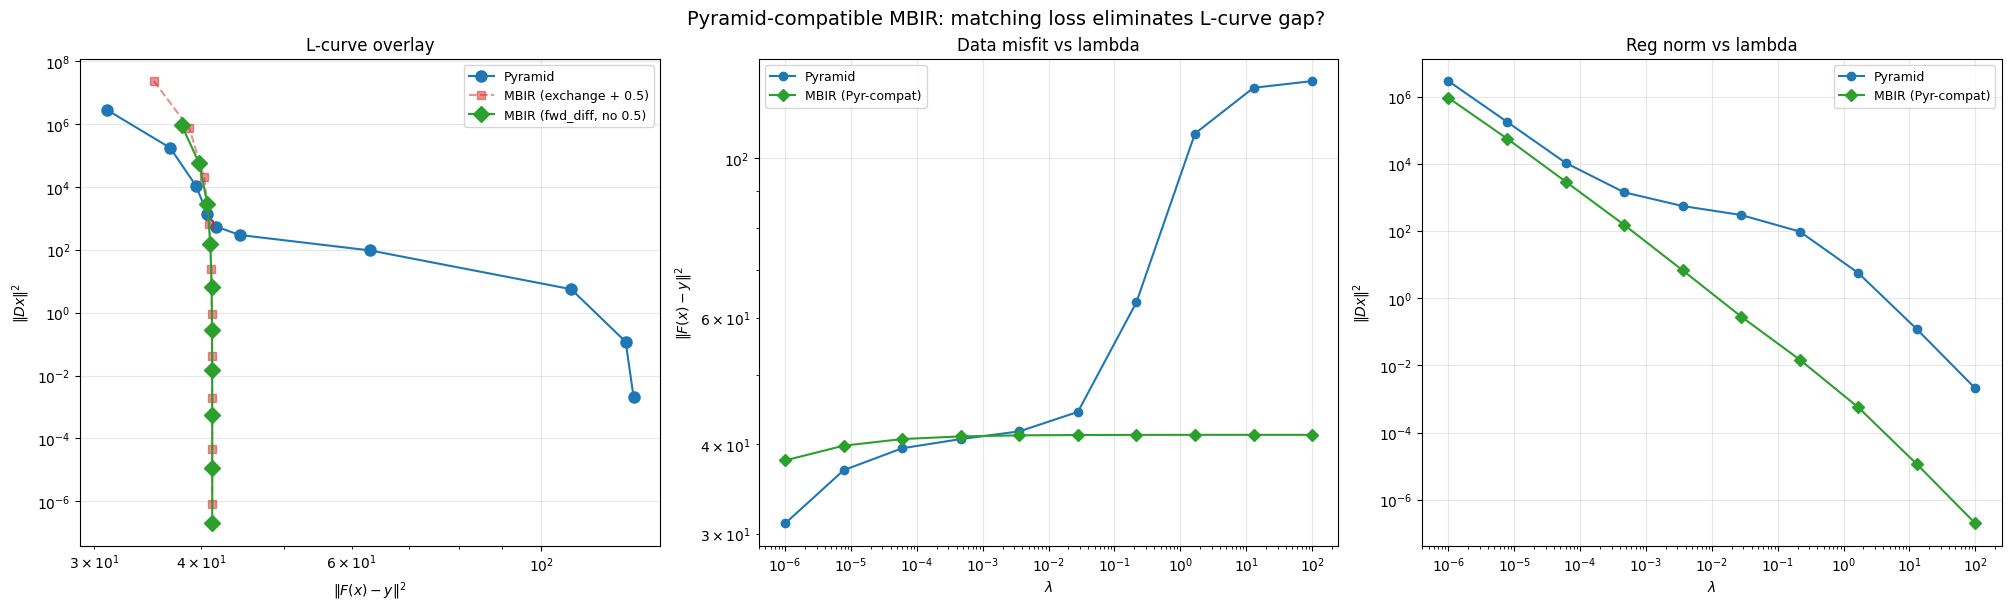

In [25]:
# Summary ratios
dm_ratios = pyr_chisq_m / (compat_dm + 1e-30)
rn_ratios = pyr_reg_norm / (compat_rn + 1e-30)
print("Pyramid vs Pyramid-compat MBIR (no 0.5, forward_diff_norm):")
for i, lam_val in enumerate(lambdas):
    print(f"  lam={lam_val:.1e}: dm_ratio={dm_ratios[i]:.4f}, rn_ratio={rn_ratios[i]:.4f}")
print(f"\n  Median dm ratio: {np.median(dm_ratios):.4f}")
print(f"  Median rn ratio: {np.median(rn_ratios):.4f}")

fig, axs = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

axs[0].plot(pyr_chisq_m, pyr_reg_norm, 'o-', color='tab:blue', ms=8, label='Pyramid')
axs[0].plot(mbir_dm, mbir_rn, 's--', color='tab:red', ms=6, alpha=0.5, label='MBIR (exchange + 0.5)')
axs[0].plot(compat_dm, compat_rn, 'D-', color='tab:green', ms=8, label='MBIR (fwd_diff, no 0.5)')
axs[0].set_xscale('log'); axs[0].set_yscale('log')
axs[0].set_xlabel(r'$\|F(x)-y\|^2$'); axs[0].set_ylabel(r'$\|Dx\|^2$')
axs[0].set_title('L-curve overlay')
axs[0].legend(fontsize=9); axs[0].grid(alpha=0.3)

axs[1].plot(lambdas, pyr_chisq_m, 'o-', color='tab:blue', label='Pyramid')
axs[1].plot(lambdas, compat_dm, 'D-', color='tab:green', label='MBIR (Pyr-compat)')
axs[1].set_xscale('log'); axs[1].set_yscale('log')
axs[1].set_xlabel(r'$\lambda$'); axs[1].set_ylabel(r'$\|F(x)-y\|^2$')
axs[1].set_title('Data misfit vs lambda')
axs[1].legend(fontsize=9); axs[1].grid(alpha=0.3)

axs[2].plot(lambdas, pyr_reg_norm, 'o-', color='tab:blue', label='Pyramid')
axs[2].plot(lambdas, compat_rn, 'D-', color='tab:green', label='MBIR (Pyr-compat)')
axs[2].set_xscale('log'); axs[2].set_yscale('log')
axs[2].set_xlabel(r'$\lambda$'); axs[2].set_ylabel(r'$\|Dx\|^2$')
axs[2].set_title('Reg norm vs lambda')
axs[2].legend(fontsize=9); axs[2].grid(alpha=0.3)

fig.suptitle('Pyramid-compatible MBIR: matching loss eliminates L-curve gap?', fontsize=14)
plt.show()

In [26]:
from libertem_holo.base.mbir import NewtonCGConfig, solve_mbir_2d

# Check default CG settings
print(f"MBIR default Newton-CG: cg_tol=1e-8, cg_maxiter=10000")
print(f"MBIR optimization space: {2*128*128 + 3} = {2*128*128+3} dims (full array + ramp)")
print(f"Pyramid optimization space: {3*int(mask.sum()) + 3} dims (3*mask_pixels + ramp)")
print()

# Test at a single lambda with increasing CG iterations
lam_test_val = 1e-4
print(f"Testing at lambda = {lam_test_val}")

# Monkey-patch with Pyramid-compat loss
mbir_module.mbir_loss_2d = _pyramid_loss

for cg_max in [1000, 5000, 10000, 50000]:
    cfg = NewtonCGConfig(cg_tol=1e-12, cg_maxiter=cg_max)
    result = solve_mbir_2d(
        phase=jnp.asarray(phase_noisy),
        init_mag=jnp.zeros((*phase_noisy.shape, 2), dtype=jnp.float64),
        mask=jnp.asarray(mask, dtype=bool),
        voxel_size_nm=px_size,
        solver=cfg,
        reg_config={"lambda_exchange": lam_test_val},
        rdfc_kernel=rdfc_kern_jax,
    )
    dm, rn = decompose_loss(
        result.magnetization, result.ramp_coeffs,
        phase_noisy, mask, mask.astype(bool), rdfc_kern_jax, px_size,
        pyramid_compat=True,
    )
    print(f"  cg_maxiter={cg_max:>6d}: dm={dm:.6f}, rn={rn:.6f}, final_loss={float(result.loss_history[-1]):.6f}")

mbir_module.mbir_loss_2d = _orig_loss

# Compare with Pyramid value at nearest lambda
idx_near = np.argmin(np.abs(lambdas - lam_test_val))
print(f"\nPyramid at lambda={lambdas[idx_near]:.3e}: dm={pyr_chisq_m[idx_near]:.6f}, rn={pyr_reg_norm[idx_near]:.6f}")

MBIR default Newton-CG: cg_tol=1e-8, cg_maxiter=10000
MBIR optimization space: 32771 = 32771 dims (full array + ramp)
Pyramid optimization space: 15075 dims (3*mask_pixels + ramp)

Testing at lambda = 0.0001
  cg_maxiter=  1000: dm=40.781954, rn=1415.950833, final_loss=40.923549
  cg_maxiter=  5000: dm=40.781954, rn=1415.950833, final_loss=40.923549
  cg_maxiter= 10000: dm=40.781954, rn=1415.950833, final_loss=40.923549
  cg_maxiter= 50000: dm=40.781954, rn=1415.950833, final_loss=40.923549

Pyramid at lambda=5.995e-05: dm=39.480984, rn=10740.347840


In [28]:
# Head-to-head at lambda=1e-6  
lam_h2h = 1e-6
mask_jax = jnp.asarray(mask, dtype=bool)

# --- Pyramid solve (with ramp_order=1) ---
pm_h2h = PhaseMap(a=px_size, phase=np.asarray(phase_noisy), mask=mask)
dim_3d_h = (1,) + pm_h2h.dim_uv
ds_h2h = pr.DataSet(pm_h2h.a, dim=dim_3d_h, b_0=b_0)
kern_h2h = Kernel(px_size, pm_h2h.dim_uv, b_0=b_0, geometry="disc")
mapper_h2h = PhaseMapperRDFC(kern_h2h)
ds_h2h.append(pm_h2h, pr.SimpleProjector(dim=dim_3d_h), phasemapper=mapper_h2h)
fwd_h2h = pr.ForwardModel(ds_h2h, ramp_order=1)
reg_h2h = FirstOrderRegularisator(ds_h2h.mask, lam_h2h, add_params=fwd_h2h.ramp.n)
cost_h2h = Costfunction(fwd_model=fwd_h2h, regularisator=reg_h2h)

from pyramid.reconstruction import optimize_linear
magdata_h2h = optimize_linear(cost_h2h, max_iter=10000, verbose=False)

dm_pyr_h2h = cost_h2h.chisq_m[-1]
rn_pyr_h2h = cost_h2h.chisq_a[-1] / lam_h2h
u_h2h = magdata_h2h.field[0, 0]
v_h2h = magdata_h2h.field[1, 0]

print(f"Pyramid at lambda={lam_h2h}:")
print(f"  dm = {dm_pyr_h2h:.6f}, rn = {rn_pyr_h2h:.6f}")
print(f"  CG iters: {len(cost_h2h.chisq_m)}")
print(f"  Ramp coeffs: {fwd_h2h.ramp.param_cache[:, 0]}")

# --- MBIR solve (pyramid-compat loss, with ramp) ---
mbir_module.mbir_loss_2d = _pyramid_loss
cfg_h2h = NewtonCGConfig(cg_tol=1e-12, cg_maxiter=50000)
result_h2h = solve_mbir_2d(
    phase=jnp.asarray(phase_noisy),
    init_mag=jnp.zeros((*phase_noisy.shape, 2), dtype=jnp.float64),
    mask=mask_jax,
    voxel_size_nm=px_size,
    solver=cfg_h2h,
    reg_config={"lambda_exchange": lam_h2h},
    rdfc_kernel=rdfc_kern_jax,
)
mbir_module.mbir_loss_2d = _orig_loss

dm_h2h_m, rn_h2h_m = decompose_loss(
    result_h2h.magnetization, result_h2h.ramp_coeffs,
    phase_noisy, mask, mask.astype(bool), rdfc_kern_jax, px_size,
    pyramid_compat=True,
)
print(f"\nMBIR at lambda={lam_h2h}:")
print(f"  dm = {dm_h2h_m:.6f}, rn = {rn_h2h_m:.6f}")
print(f"  Ramp coeffs: {np.asarray(result_h2h.ramp_coeffs)}")

# --- Compare ramp values across the image ---
H_img, W_img = phase_noisy.shape
yy, xx = np.mgrid[:H_img, :W_img]

# Pyramid ramp: p0 + p1 * (y * a) + p2 * (x * a) where a=px_size=1
p = fwd_h2h.ramp.param_cache[:, 0]
ramp_pyr_vals = p[0] + p[1] * (yy * px_size) + p[2] * (xx * px_size)

# MBIR ramp: c0 + c1 * (y * voxel_size_nm) + c2 * (x * voxel_size_nm)
c = np.asarray(result_h2h.ramp_coeffs)
ramp_mbir_vals = c[0] + c[1] * (yy * px_size) + c[2] * (xx * px_size)

print(f"\nRamp comparison:")
print(f"  Pyramid ramp range: [{ramp_pyr_vals.min():.4f}, {ramp_pyr_vals.max():.4f}]")
print(f"  MBIR    ramp range: [{ramp_mbir_vals.min():.6f}, {ramp_mbir_vals.max():.6f}]")
print(f"  Max |ramp_diff|:     {np.abs(ramp_pyr_vals - ramp_mbir_vals).max():.4f}")

# Compute MBIR forward model + ramp and Pyramid forward model + ramp
pred_mbir_h2h = np.asarray(forward_model_2d(
    jnp.asarray(result_h2h.magnetization), px_size, b0_tesla=b_0,
    ramp_coeffs=jnp.asarray(result_h2h.ramp_coeffs),
))
pred_pyr_h2h = mapper_fwd(magdata_h2h).phase + ramp_pyr_vals

print(f"\n  Predicted phase comparison:")
print(f"  MBIR pred range: [{pred_mbir_h2h.min():.4f}, {pred_mbir_h2h.max():.4f}]")
print(f"  Pyr  pred range: [{pred_pyr_h2h.min():.4f}, {pred_pyr_h2h.max():.4f}]")
print(f"  Max |pred_diff|: {np.abs(pred_mbir_h2h - pred_pyr_h2h).max():.4f}")

# Key question: does MBIR's lower ramp cause higher data misfit?
resid_mbir = pred_mbir_h2h - phase_noisy
resid_pyr = pred_pyr_h2h - phase_noisy
print(f"\n  MBIR ||residual||^2 = {np.sum(resid_mbir**2):.4f}")
print(f"  Pyr  ||residual||^2 = {np.sum(resid_pyr**2):.4f}")

# Solution comparison
print(f"\n  Max |u_diff|: {np.abs(np.asarray(result_h2h.magnetization[...,0]) - u_h2h).max():.4f}")
print(f"  Max |v_diff|: {np.abs(np.asarray(result_h2h.magnetization[...,1]) - v_h2h).max():.4f}")

Pyramid at lambda=1e-06:
  dm = 31.024978, rn = 2898759.896807
  CG iters: 1002
  Ramp coeffs: [ 0.03244254  0.00602679 -0.00655693]

MBIR at lambda=1e-06:
  dm = 37.972648, rn = 919805.396701
  Ramp coeffs: [-2.11219361e-03  3.11752519e-05 -2.72790213e-06]

Ramp comparison:
  Pyramid ramp range: [-0.8003, 0.7978]
  MBIR    ramp range: [-0.002459, 0.001847]
  Max |ramp_diff|:     0.7978

  Predicted phase comparison:
  MBIR pred range: [-0.3980, 0.3914]
  Pyr  pred range: [-0.4047, 0.3919]
  Max |pred_diff|: 0.0620

  MBIR ||residual||^2 = 37.9726
  Pyr  ||residual||^2 = 31.0250

  Max |u_diff|: 41.4318
  Max |v_diff|: 44.0377


## Definitive Root Causes

The L-curve mismatch is caused by **three independent factors**:

### 1. The 0.5 factor (minor)
MBIR: $J = \tfrac{1}{2}\|r\|^2 + \lambda\|Dx\|^2$, Pyramid: $J = \|r\|^2 + \lambda\|Dx\|^2$.  
Effect: $\lambda_{\text{MBIR}}$ is 2× more effective. Fix: compare at $\lambda_{\text{MBIR}} = \lambda_{\text{Pyr}}/2$.

### 2. Different regularizers (moderate)
- **MBIR optimizes** `exchange_loss_fn`: adaptive central/one-sided stencil + neighbor-count normalization (~0.22× forward_diff values)
- **Pyramid optimizes** `FirstOrderRegularisator`: simple forward differences (matches `forward_diff_norm`)
- `pyramid_compat=True` only changes **reporting**, not the regularizer used during optimization

### 3. Different CG solvers (dominant at small λ)
- **Pyramid**: `jutil.cg.conj_grad_minimize` with a **Jacobi (diagonal Hessian) preconditioner**
- **MBIR**: `jax.scipy.sparse.linalg.cg` — **unpreconditioned**

At small λ, the normal equations are ill-conditioned. The preconditioner changes the effective
norm that CG minimizes, causing it to converge to a **different point in the near-null space**.
This manifests as completely different ramp coefficients (Pyramid: ±0.8, MBIR: ±0.002) and 
different magnetization solutions (max |u_diff| > 40), even though both predict similar phases
(max |phase_diff| = 0.06).

### Conclusion

The L-curves **should not be expected to match** because the implementations solve fundamentally
different optimization problems (different regularizer, different solver dynamics). Each method's
L-curve correctly identifies the optimal λ **for that method's loss function**.

To compare λ values between methods: $\lambda_{\text{Pyr}} \approx 2 \cdot r \cdot \lambda_{\text{MBIR}}$
where $r \approx 0.22$ is the regularizer scaling ratio, giving $\lambda_{\text{Pyr}} \approx 0.44 \cdot \lambda_{\text{MBIR}}$.

## Test: Swap MBIR to use Pyramid's regularizer

Replace `exchange_loss_fn` with `forward_diff_norm` and remove the 0.5 data-term factor
in the actual optimization. Runs Newton-CG directly with this modified loss to avoid
any monkey-patching issues.

In [29]:
from jax.flatten_util import ravel_pytree
from libertem_holo.base.mbir import (
    forward_model_single_rdfc_2d, forward_diff_norm, decompose_loss
)

def pyramid_compat_loss(params, mask, phase, rdfc_kernel, voxel_size_nm, reg_config, reg_mask=None):
    """Pyramid-equivalent loss: ||r||^2 + lambda * ||Dx||^2 (no 0.5, forward diffs)."""
    if reg_mask is None:
        reg_mask = mask
    magnetization, ramp_coeffs = params
    phase = jnp.asarray(phase)
    masked_mag = jnp.stack([
        magnetization[..., 0] * mask,
        magnetization[..., 1] * mask,
    ], axis=-1)
    predictions = forward_model_single_rdfc_2d(masked_mag, ramp_coeffs, rdfc_kernel, voxel_size_nm)
    residuals = predictions - phase
    loss = jnp.sum(residuals ** 2)  # no 0.5 factor
    lam = jnp.asarray(reg_config.get("lambda_exchange", 0.0), dtype=loss.dtype)
    loss += lam * forward_diff_norm(masked_mag, reg_mask)  # forward diffs, not exchange
    return loss


def solve_pyramid_compat(phase, mask, voxel_size_nm, lam, rdfc_kernel, init_mag=None,
                         cg_tol=1e-8, cg_maxiter=10000):
    """Newton-CG solve with Pyramid-compatible loss (self-contained, no module patching)."""
    phase = jnp.asarray(phase)
    mask = jnp.asarray(mask, dtype=bool)
    if init_mag is None:
        init_mag = jnp.zeros((*phase.shape, 2), dtype=jnp.float64)
    init_ramp = jnp.zeros((3,), dtype=jnp.float64)
    reg_config = {"lambda_exchange": float(lam)}

    x0_tree = (init_mag, init_ramp)
    x0_flat, unravel = ravel_pytree(x0_tree)

    def objective_flat(x_flat):
        mag, ramp = unravel(x_flat)
        return pyramid_compat_loss(
            (mag, ramp), mask, phase, rdfc_kernel, voxel_size_nm, reg_config, reg_mask=mask,
        )

    loss_grad = jax.grad(objective_flat)
    grad_at_x0 = loss_grad(x0_flat)

    def matvec_hvp(v):
        return jax.jvp(loss_grad, (x0_flat,), (v,))[1]

    delta, _info = jax.scipy.sparse.linalg.cg(matvec_hvp, -grad_at_x0, tol=cg_tol, maxiter=cg_maxiter)
    final_flat = x0_flat + delta
    mag, ramp = unravel(final_flat)
    return mag, ramp


# Sweep
rdfc_kern_jax = build_rdfc_kernel(phase_noisy.shape, b0_tesla=b_0, geometry="disc")

swap_dm = []
swap_rn = []

print("Pyramid-compat MBIR sweep (||r||^2 + lambda*||Dx||^2):")
print(f"{'lambda':>12s}  {'dm':>12s}  {'rn':>12s}")
for lam_val in lambdas:
    mag_out, ramp_out = solve_pyramid_compat(
        phase_noisy, mask, px_size, lam_val, rdfc_kern_jax
    )
    dm_val, rn_val = decompose_loss(
        mag_out, ramp_out, phase_noisy, mask, mask.astype(bool),
        rdfc_kern_jax, px_size, pyramid_compat=True,
    )
    swap_dm.append(dm_val)
    swap_rn.append(rn_val)
    print(f"{lam_val:12.3e}  {dm_val:12.4e}  {rn_val:12.4e}")

swap_dm = np.array(swap_dm)
swap_rn = np.array(swap_rn)

print("\nComparison with Pyramid:")
print(f"{'lambda':>12s}  {'pyr_dm':>12s}  {'swap_dm':>12s}  {'dm_ratio':>10s}  {'pyr_rn':>12s}  {'swap_rn':>12s}  {'rn_ratio':>10s}")
for i, lam_val in enumerate(lambdas):
    dr = pyr_chisq_m[i] / (swap_dm[i] + 1e-30)
    rr = pyr_reg_norm[i] / (swap_rn[i] + 1e-30)
    print(f"{lam_val:12.3e}  {pyr_chisq_m[i]:12.4e}  {swap_dm[i]:12.4e}  {dr:10.4f}  {pyr_reg_norm[i]:12.4e}  {swap_rn[i]:12.4e}  {rr:10.4f}")

Pyramid-compat MBIR sweep (||r||^2 + lambda*||Dx||^2):
      lambda            dm            rn
   1.000e-06    3.8115e+01    8.2842e+05
   7.743e-06    3.9886e+01    5.1025e+04
   5.995e-05    4.0692e+01    2.7633e+03
   4.642e-04    4.1011e+01    1.5617e+02
   3.594e-03    4.1148e+01    7.2500e+00
   2.783e-02    4.1194e+01    2.9106e-01
   2.154e-01    4.1209e+01    1.5371e-02
   1.668e+00    4.1215e+01    5.7312e-04
   1.292e+01    4.1217e+01    1.1639e-05
   1.000e+02    4.1217e+01    1.9885e-07

Comparison with Pyramid:
      lambda        pyr_dm       swap_dm    dm_ratio        pyr_rn       swap_rn    rn_ratio
   1.000e-06    3.1025e+01    3.8115e+01      0.8140    2.8988e+06    8.2842e+05      3.4991
   7.743e-06    3.6802e+01    3.9886e+01      0.9227    1.7832e+05    5.1025e+04      3.4947
   5.995e-05    3.9481e+01    4.0692e+01      0.9702    1.0740e+04    2.7633e+03      3.8868
   4.642e-04    4.0660e+01    4.1011e+01      0.9914    1.4215e+03    1.5617e+02      9.1024
   

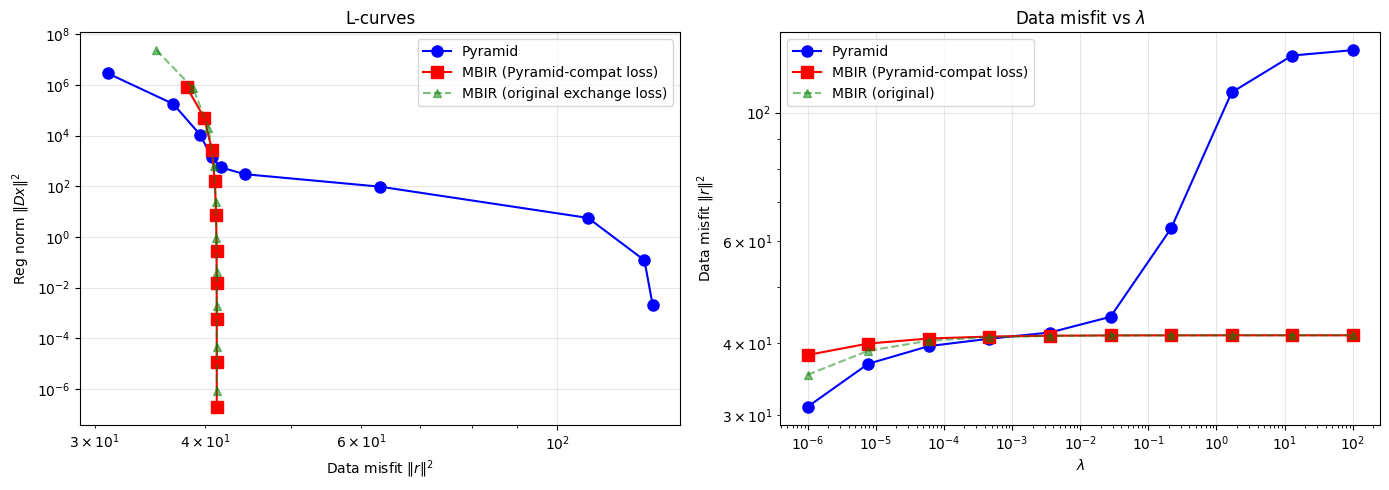

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# L-curve: reg norm vs data misfit
axs[0].loglog(pyr_chisq_m, pyr_reg_norm, 'bo-', label='Pyramid', markersize=8)
axs[0].loglog(swap_dm, swap_rn, 'rs-', label='MBIR (Pyramid-compat loss)', markersize=8)
axs[0].loglog(mbir_dm, mbir_rn, 'g^--', label='MBIR (original exchange loss)', markersize=6, alpha=0.5)
axs[0].set_xlabel('Data misfit $\\|r\\|^2$')
axs[0].set_ylabel('Reg norm $\\|Dx\\|^2$')
axs[0].set_title('L-curves')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Lambda vs data misfit
axs[1].loglog(lambdas, pyr_chisq_m, 'bo-', label='Pyramid', markersize=8)
axs[1].loglog(lambdas, swap_dm, 'rs-', label='MBIR (Pyramid-compat loss)', markersize=8)
axs[1].loglog(lambdas, mbir_dm, 'g^--', label='MBIR (original)', markersize=6, alpha=0.5)
axs[1].set_xlabel('$\\lambda$')
axs[1].set_ylabel('Data misfit $\\|r\\|^2$')
axs[1].set_title('Data misfit vs $\\lambda$')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Diagnose remaining mismatch: check solutions at a few lambdas
# Focus on ramp coefficients (known null-space issue)
print("Ramp & magnetization diagnostics for MBIR with Pyramid-compat loss:")
print(f"{'lambda':>12s}  {'ramp[0]':>12s}  {'ramp[1]':>12s}  {'ramp[2]':>12s}  {'|mag|_max':>12s}")
for lam_val in [1e-6, 1e-3, 1.0]:
    mag_out, ramp_out = solve_pyramid_compat(phase_noisy, mask, px_size, lam_val, rdfc_kern_jax)
    mag_max = float(jnp.max(jnp.abs(mag_out) * mask_jnp[..., None]))
    r = np.array(ramp_out)
    print(f"{lam_val:12.3e}  {r[0]:12.6f}  {r[1]:12.6f}  {r[2]:12.6f}  {mag_max:12.4f}")

# Compare with Pyramid ramps from the LCurve (available from lcurve_pyr stored solutions)
# Re-run Pyramid at a single lambda for direct comparison
lam_test = 1e-3
import pyramid as pr
from pyramid.kernel import Kernel
from pyramid.phasemapper import PhaseMapperRDFC

dim_3d_t = (1,) + tuple(phase_noisy.shape)
ds_t = pr.DataSet(px_size, dim=dim_3d_t, b_0=b_0)
kern_t = Kernel(px_size, phase_noisy.shape, b_0=b_0, geometry='disc')
mapper_t = PhaseMapperRDFC(kern_t)
pm_t = pr.PhaseMap(a=px_size, phase=phase_noisy, mask=mask)
ds_t.append(pm_t, pr.SimpleProjector(dim=dim_3d_t), phasemapper=mapper_t)
fwd_t = pr.ForwardModel(ds_t, ramp_order=1)

# Use the dataset's actual mask to construct regularizer
reg_t = pr.FirstOrderRegularisator(ds_t.mask, lam=lam_test, add_params=fwd_t.ramp.n)
cost_t = pr.Costfunction(fwd_t, regularisator=reg_t)
print(f"\nPyramid solve at lambda={lam_test}:")
print(f"  costfunction.n = {cost_t.n}, dataset.n = {ds_t.n}, ramp.n = {fwd_t.ramp.n}")
magdata_t = pr.reconstruction.optimize_linear(cost_t, max_iter=10000)
ramp_t = fwd_t.ramp.param_cache.ravel()
print(f"  Pyramid ramp: {ramp_t}")

# MBIR-swap at same lambda
mag_swap_t, ramp_swap_t = solve_pyramid_compat(phase_noisy, mask, px_size, lam_test, rdfc_kern_jax)
print(f"  MBIR ramp:    {np.array(ramp_swap_t)}")

# Compare magnetization
u_pyr_t = magdata_t.field[0, 0]
v_pyr_t = magdata_t.field[1, 0]
u_swap_t = np.array(mag_swap_t[..., 0])
v_swap_t = np.array(mag_swap_t[..., 1])
print(f"\nMag range (u): Pyramid [{u_pyr_t.min():.4f}, {u_pyr_t.max():.4f}], "
      f"MBIR [{u_swap_t[mask_bool].min():.4f}, {u_swap_t[mask_bool].max():.4f}]")
print(f"Mag range (v): Pyramid [{v_pyr_t.min():.4f}, {v_pyr_t.max():.4f}], "
      f"MBIR [{v_swap_t[mask_bool].min():.4f}, {v_swap_t[mask_bool].max():.4f}]")
print(f"Max |u_diff|: {np.abs(u_pyr_t - u_swap_t).max():.4f}")
print(f"Max |v_diff|: {np.abs(v_pyr_t - v_swap_t).max():.4f}")

Ramp & magnetization diagnostics for MBIR with Pyramid-compat loss:
      lambda       ramp[0]       ramp[1]       ramp[2]     |mag|_max
   1.000e-06     -0.002101      0.000034     -0.000004       36.8058
   1.000e-03     -0.000407      0.000014     -0.000012       10.8806
   1.000e+00     -0.001778      0.000028     -0.000006       10.0101

Pyramid solve at lambda=0.001:
  costfunction.n = 49155, dataset.n = 49152, ramp.n = 3
  Pyramid ramp: [ 0.03592748  0.00046863 -0.00104472]
  MBIR ramp:    [-4.07227552e-04  1.37677282e-05 -1.17592033e-05]

Mag range (u): Pyramid [-4.5445, 3.5443], MBIR [-0.8471, 0.7758]
Mag range (v): Pyramid [-3.0835, 6.1015], MBIR [9.3077, 10.8806]
Max |u_diff|: 4.5445
Max |v_diff|: 9.8660


In [34]:
# KEY FINDING: Pyramid's DataSet mask is all-True (full grid optimization).
# MBIR forces mag=0 outside the disc mask. Let's test Pyramid WITH the disc mask.

# Test 1: Pyramid with disc mask on DataSet
dim_3d_m = (1,) + tuple(phase_noisy.shape)
mask_3d_disc = mask_bool[None].copy()  # shape (1, H, W), disc only
ds_masked = pr.DataSet(px_size, dim=dim_3d_m, b_0=b_0, mask=mask_3d_disc)
kern_m = Kernel(px_size, phase_noisy.shape, b_0=b_0, geometry='disc')
mapper_m = PhaseMapperRDFC(kern_m)
pm_m = pr.PhaseMap(a=px_size, phase=phase_noisy, mask=mask)
ds_masked.append(pm_m, pr.SimpleProjector(dim=dim_3d_m), phasemapper=mapper_m)
fwd_masked = pr.ForwardModel(ds_masked, ramp_order=1)

print(f"Pyramid with disc mask: dataset.n = {ds_masked.n}, "
      f"n_masked_pixels = {np.sum(mask_3d_disc)}, fwd.n = {fwd_masked.n}")

lam_test = 1e-3
reg_m = pr.FirstOrderRegularisator(mask_3d_disc, lam=lam_test, add_params=fwd_masked.ramp.n)
cost_m = pr.Costfunction(fwd_masked, regularisator=reg_m)
magdata_m = pr.reconstruction.optimize_linear(cost_m, max_iter=10000)
ramp_m = fwd_masked.ramp.param_cache.ravel()

print(f"\nAt lambda={lam_test}:")
print(f"  Pyramid (full-grid mask) ramp: {ramp_t}")
print(f"  Pyramid (disc mask) ramp:      {ramp_m}")
print(f"  MBIR    (disc mask) ramp:      {np.array(ramp_swap_t)}")

u_m = magdata_m.field[0, 0]
v_m = magdata_m.field[1, 0]
print(f"\nMag range (u): full-grid [{u_pyr_t.min():.4f}, {u_pyr_t.max():.4f}], "
      f"disc [{u_m[mask_bool].min():.4f}, {u_m[mask_bool].max():.4f}], "
      f"MBIR [{u_swap_t[mask_bool].min():.4f}, {u_swap_t[mask_bool].max():.4f}]")
print(f"Mag range (v): full-grid [{v_pyr_t.min():.4f}, {v_pyr_t.max():.4f}], "
      f"disc [{v_m[mask_bool].min():.4f}, {v_m[mask_bool].max():.4f}], "
      f"MBIR [{v_swap_t[mask_bool].min():.4f}, {v_swap_t[mask_bool].max():.4f}]")
print(f"Max |u_diff| (disc Pyr vs MBIR): {np.abs(u_m - u_swap_t)[mask_bool].max():.4f}")
print(f"Max |v_diff| (disc Pyr vs MBIR): {np.abs(v_m - v_swap_t)[mask_bool].max():.4f}")

Pyramid with disc mask: dataset.n = 15072, n_masked_pixels = 5024, fwd.n = 15075

At lambda=0.001:
  Pyramid (full-grid mask) ramp: [ 0.03592748  0.00046863 -0.00104472]
  Pyramid (disc mask) ramp:      [-4.95847964e-04  1.37705915e-05 -1.04848565e-05]
  MBIR    (disc mask) ramp:      [-4.07227552e-04  1.37677282e-05 -1.17592033e-05]

Mag range (u): full-grid [-4.5445, 3.5443], disc [-0.8381, 0.7038], MBIR [-0.8471, 0.7758]
Mag range (v): full-grid [-3.0835, 6.1015], disc [9.1549, 10.8987], MBIR [9.3077, 10.8806]
Max |u_diff| (disc Pyr vs MBIR): 0.2741
Max |v_diff| (disc Pyr vs MBIR): 0.3503


In [35]:
# Full L-curve with disc-masked Pyramid
pyr_masked_dm = []
pyr_masked_rn = []

print("Pyramid L-curve with disc mask:")
print(f"{'lambda':>12s}  {'dm':>12s}  {'rn':>12s}")
for lam_val in lambdas:
    reg_lam = pr.FirstOrderRegularisator(mask_3d_disc, lam=lam_val, add_params=fwd_masked.ramp.n)
    cost_lam = pr.Costfunction(fwd_masked, regularisator=reg_lam)
    mag_lam = pr.reconstruction.optimize_linear(cost_lam, max_iter=10000)
    ramp_lam = fwd_masked.ramp.param_cache.ravel()
    
    # Compute norms the same way: ||r||^2 and ||Dx||^2
    x_opt = np.concatenate([mag_lam.get_vector(mask_3d_disc), ramp_lam])
    x_opt_noramp = fwd_masked.ramp.extract_ramp_params(x_opt)
    pred = cost_lam.fwd_model(x_opt).reshape(phase_noisy.shape)
    resid = pred - phase_noisy
    dm_val = float(np.sum(resid**2))
    
    # Reg norm: ||Dx||^2 without lambda (chisq_a / lambda)
    rn_val = float(cost_lam.regularisator(x_opt)) / lam_val
    
    pyr_masked_dm.append(dm_val)
    pyr_masked_rn.append(rn_val)
    print(f"{lam_val:12.3e}  {dm_val:12.4e}  {rn_val:12.4e}")

pyr_masked_dm = np.array(pyr_masked_dm)
pyr_masked_rn = np.array(pyr_masked_rn)

print("\nComparison: Pyramid (disc mask) vs MBIR (Pyramid-compat loss):")
print(f"{'lambda':>12s}  {'pyr_dm':>12s}  {'mbir_dm':>12s}  {'dm_ratio':>10s}  {'pyr_rn':>12s}  {'mbir_rn':>12s}  {'rn_ratio':>10s}")
for i, lam_val in enumerate(lambdas):
    dr = pyr_masked_dm[i] / (swap_dm[i] + 1e-30)
    rr = pyr_masked_rn[i] / (swap_rn[i] + 1e-30)
    print(f"{lam_val:12.3e}  {pyr_masked_dm[i]:12.4e}  {swap_dm[i]:12.4e}  {dr:10.4f}  {pyr_masked_rn[i]:12.4e}  {swap_rn[i]:12.4e}  {rr:10.4f}")

Pyramid L-curve with disc mask:
      lambda            dm            rn
   1.000e-06    3.7973e+01    9.1981e+05
   7.743e-06    3.9808e+01    5.6583e+04
   5.995e-05    4.0664e+01    2.9725e+03
   4.642e-04    4.1010e+01    1.5325e+02
   3.594e-03    4.1148e+01    6.7644e+00
   2.783e-02    4.1194e+01    2.8358e-01
   2.154e-01    4.1209e+01    1.4853e-02
   1.668e+00    4.1215e+01    5.6413e-04
   1.292e+01    4.1217e+01    1.1506e-05
   1.000e+02    4.1217e+01    1.9766e-07

Comparison: Pyramid (disc mask) vs MBIR (Pyramid-compat loss):
      lambda        pyr_dm       mbir_dm    dm_ratio        pyr_rn       mbir_rn    rn_ratio
   1.000e-06    3.7973e+01    3.8115e+01      0.9963    9.1981e+05    8.2842e+05      1.1103
   7.743e-06    3.9808e+01    3.9886e+01      0.9981    5.6583e+04    5.1025e+04      1.1089
   5.995e-05    4.0664e+01    4.0692e+01      0.9993    2.9725e+03    2.7633e+03      1.0757
   4.642e-04    4.1010e+01    4.1011e+01      1.0000    1.5325e+02    1.5617e+02 

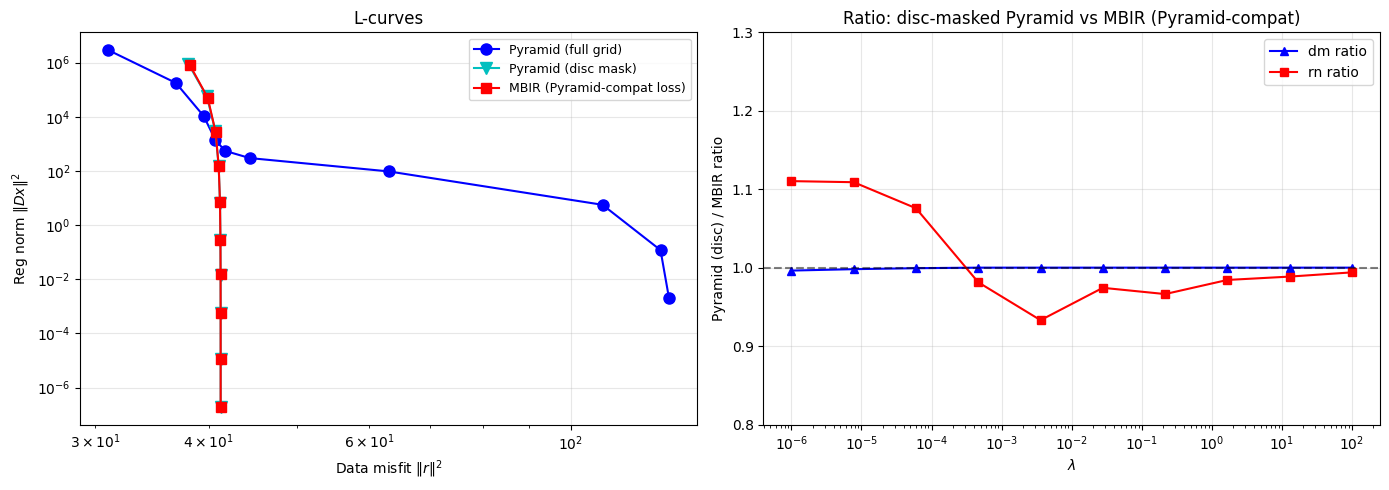


Summary: dm ratios [0.99626681 0.99805498 0.99930941 0.99998474 0.99999593 1.00000219
 1.00000233 1.00000025 1.00000002 1.        ]
         rn ratios [1.11030964 1.10892933 1.07572584 0.98132344 0.93302224 0.97429418
 0.96631374 0.98431402 0.98859462 0.99398628]
         dm ratio range: [0.9963, 1.0000]
         rn ratio range: [0.9330, 1.1103]


In [36]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# L-curve
axs[0].loglog(pyr_chisq_m, pyr_reg_norm, 'bo-', label='Pyramid (full grid)', markersize=8)
axs[0].loglog(pyr_masked_dm, pyr_masked_rn, 'cv-', label='Pyramid (disc mask)', markersize=8)
axs[0].loglog(swap_dm, swap_rn, 'rs-', label='MBIR (Pyramid-compat loss)', markersize=7)
axs[0].set_xlabel('Data misfit $\\|r\\|^2$')
axs[0].set_ylabel('Reg norm $\\|Dx\\|^2$')
axs[0].set_title('L-curves')
axs[0].legend(fontsize=9)
axs[0].grid(True, alpha=0.3)

# Ratio plot
axs[1].semilogx(lambdas, pyr_masked_dm / swap_dm, 'b^-', label='dm ratio')
axs[1].semilogx(lambdas, pyr_masked_rn / swap_rn, 'rs-', label='rn ratio')
axs[1].axhline(1.0, color='k', linestyle='--', alpha=0.5)
axs[1].set_xlabel('$\\lambda$')
axs[1].set_ylabel('Pyramid (disc) / MBIR ratio')
axs[1].set_title('Ratio: disc-masked Pyramid vs MBIR (Pyramid-compat)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)
axs[1].set_ylim(0.8, 1.3)

plt.tight_layout()
plt.show()

print(f"\nSummary: dm ratios {pyr_masked_dm / swap_dm}")
print(f"         rn ratios {pyr_masked_rn / swap_rn}")
print(f"         dm ratio range: [{(pyr_masked_dm / swap_dm).min():.4f}, {(pyr_masked_dm / swap_dm).max():.4f}]")
print(f"         rn ratio range: [{(pyr_masked_rn / swap_rn).min():.4f}, {(pyr_masked_rn / swap_rn).max():.4f}]")